### Training

In [20]:
# Cell 1: Import necessary packages
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np
import os


In [7]:
# Cell 2: Initialize parameters and directories
INIT_LR = 0.01
EPOCHS = 20
BS = 32

DIRECTORY = r"D:/Feature Detection/dataset/images"
CATEGORIES = ["apple fruit", "banana fruit", "cherry fruit", "chickoo fruit", "grapes fruit", "kiwi fruit", "mango fruit", "orange fruit", "strawberry fruit"]


In [8]:
# Cell 3: Load images and preprocess them
print("[INFO] loading images...")

data = []
labels = []

for category in CATEGORIES:
    path = os.path.join(DIRECTORY, category)
    for img in os.listdir(path):
        img_path = os.path.join(path, img)
        try:
            image = load_img(img_path, target_size=(224, 224))
            image = img_to_array(image)
            image = preprocess_input(image)

            data.append(image)
            labels.append(category)
        except Exception as e:
            print(f"Failed to process {img_path}: {str(e)}")



[INFO] loading images...


In [9]:
# Cell 4: Perform one-hot encoding on the labels
lb = LabelBinarizer()
labels = lb.fit_transform(labels)
print(labels.shape)

data = np.array(data, dtype="float32")
labels = np.array(labels)

print("Total images loaded:", len(data))


(360, 9)
Total images loaded: 360


In [10]:
# Cell 5: Split the data into training and testing sets
(trainX, testX, trainY, testY) = train_test_split(data, labels, test_size=0.20, stratify=labels, random_state=42)
print("Training data shape:", trainX.shape)
print("Testing data shape:", testX.shape)


Training data shape: (288, 224, 224, 3)
Testing data shape: (72, 224, 224, 3)


In [12]:
# Cell 6: Construct the training image generator for data augmentation
aug = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest")


Batch images shape: (32, 224, 224, 3)
Batch labels shape: (32, 9)


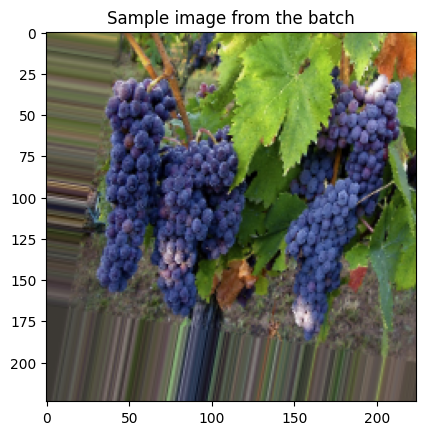

In [13]:
# Cell 7: Create the generator and fetch one batch of data
train_generator = aug.flow(trainX, trainY, batch_size=BS)

sample_images, sample_labels = next(train_generator)
print("Batch images shape:", sample_images.shape)
print("Batch labels shape:", sample_labels.shape)

# Optionally, visualize the first image in the batch to ensure it's loaded correctly
plt.imshow(sample_images[0] * 0.5 + 0.5)  # Scale images back to 0-1 range if they were preprocessed
plt.title("Sample image from the batch")
plt.show()



In [14]:
# Cell 8: Load the MobileNetV2 network
baseModel = MobileNetV2(weights="imagenet", include_top=False, input_tensor=Input(shape=(224, 224, 3)))


C:\Users\aparn\AppData\Local\Temp\ipykernel_25192\408476856.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  baseModel = MobileNetV2(weights="imagenet", include_top=False, input_tensor=Input(shape=(224, 224, 3)))


In [15]:
# Cell 9: Construct the head of the model to be placed on top of the base model
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(7, 7))(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(128, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(len(CATEGORIES), activation="softmax")(headModel)

# Place the head FC model on top of the base model
model = Model(inputs=baseModel.input, outputs=headModel)

# Freeze all layers in the base model
for layer in baseModel.layers:
    layer.trainable = False


In [16]:
# Cell 10: Compile the model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR, decay=INIT_LR / EPOCHS)
model.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"])


[INFO] compiling model...


d:\Feature Detection\feature_detection\Lib\site-packages\keras\src\optimizers\base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [17]:
# Cell 11: Train the head of the network
H = model.fit(
    aug.flow(trainX, trainY, batch_size=BS),
    validation_data=(testX, testY),
    epochs=EPOCHS
)


Epoch 1/20


d:\Feature Detection\feature_detection\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.2855 - loss: 3.2568 - val_accuracy: 0.8194 - val_loss: 0.4848
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 684ms/step - accuracy: 0.6739 - loss: 0.9130 - val_accuracy: 0.8472 - val_loss: 0.5849
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 684ms/step - accuracy: 0.8199 - loss: 0.6565 - val_accuracy: 0.9028 - val_loss: 0.3085
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 669ms/step - accuracy: 0.8314 - loss: 0.4622 - val_accuracy: 0.8889 - val_loss: 0.3354
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 690ms/step - accuracy: 0.8600 - loss: 0.4361 - val_accuracy: 0.9167 - val_loss: 0.3814
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 676ms/step - accuracy: 0.8932 - loss: 0.2820 - val_accuracy: 0.8889 - val_loss: 0.3732
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 681ms/step - accuracy: 0.8974 - loss: 0.2525 - val_accuracy: 0.9028 - val_loss: 0.2775
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 711ms/step - accuracy: 0.9271 - loss: 0.2055 - val_accuracy: 0.9028 - val_loss: 0.3698
Ep

In [18]:
# Cell 12: Make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = model.predict(testX, batch_size=BS)

# For each image in the testing set, find the index of the label with the largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)

# Show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs, target_names=lb.classes_))


[INFO] evaluating network...
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step  
                  precision    recall  f1-score   support

     apple fruit       0.73      1.00      0.84         8
    banana fruit       1.00      0.75      0.86         8
    cherry fruit       0.88      0.88      0.88         8
   chickoo fruit       0.80      1.00      0.89         8
    grapes fruit       1.00      0.75      0.86         8
      kiwi fruit       0.89      1.00      0.94         8
     mango fruit       1.00      0.88      0.93         8
    orange fruit       1.00      1.00      1.00         8
strawberry fruit       1.00      0.88      0.93         8

        accuracy                           0.90        72
       macro avg       0.92      0.90      0.90        72
    weighted avg       0.92      0.90      0.90        72



In [19]:
# Cell 13: Serialize the model to disk
print("[INFO] saving fruit classifier model...")
model.save("fruit_classifier.h5")


[INFO] saving fruit classifier model...


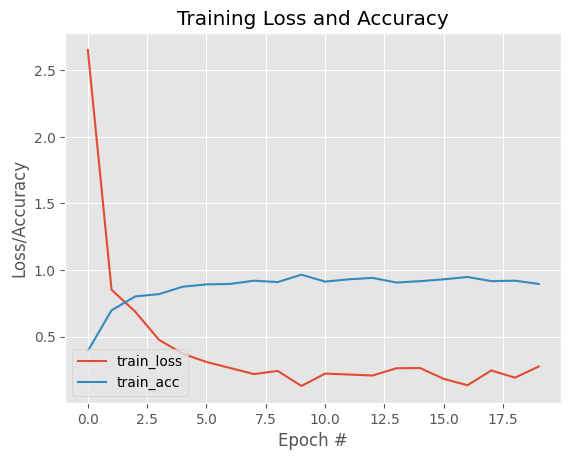

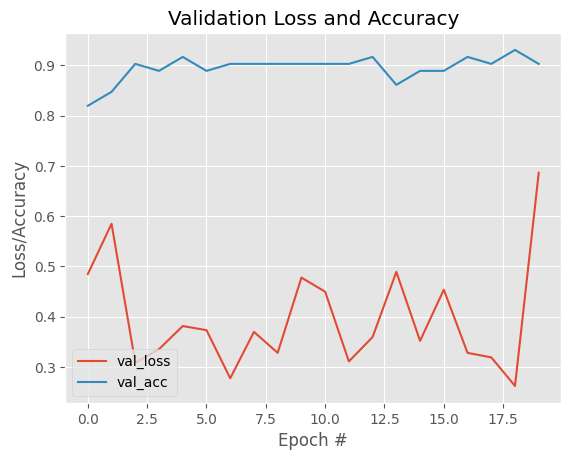

In [20]:
# Cell 14: Plot the training loss and accuracy separately
N = EPOCHS

# Plot training loss and accuracy
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
plt.savefig("train_loss_accuracy.png")

# Plot validation loss and accuracy
plt.figure()
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Validation Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
plt.savefig("val_loss_accuracy.png")



3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 315ms/step


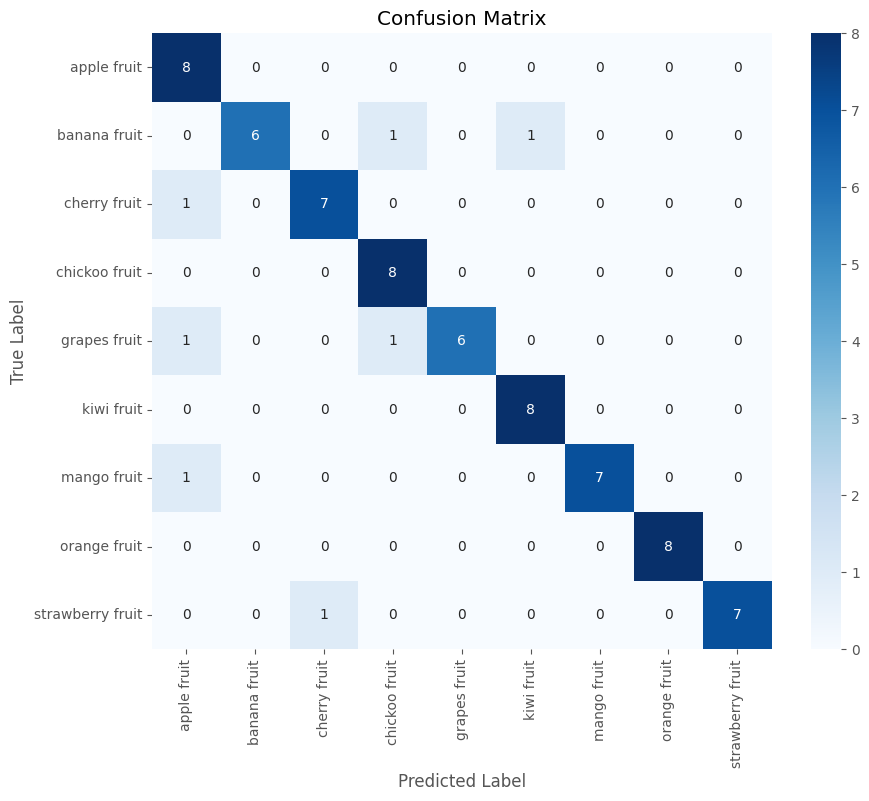

In [23]:
# Cell 15: Create a confusion matrix
# Generate predictions and the confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns

predIdxs = model.predict(testX, batch_size=BS)
predIdxs = np.argmax(predIdxs, axis=1)
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=lb.classes_, yticklabels=lb.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("confusion_matrix.png")
plt.show()

## Testing ##

In [28]:
# Cell 16: Load the trained model
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt
import numpy as np

# Load the saved model
model = load_model("fruit_classifier.h5")

In [29]:
classes = ["apple fruit", "banana fruit", "cherry fruit", "chickoo fruit", "grapes fruit", "kiwi fruit", "mango fruit", "orange fruit", "strawberry fruit"]

lb = LabelBinarizer()
lb.fit(classes)

LabelBinarizer()

In [30]:
# Cell 17: Define a function to load and preprocess an image
def prepare_image(image_path, target_size=(224, 224)):
    image = load_img(image_path, target_size=target_size)
    image = img_to_array(image)
    image = np.expand_dims(image, axis=0)
    image = preprocess_input(image)
    return image


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


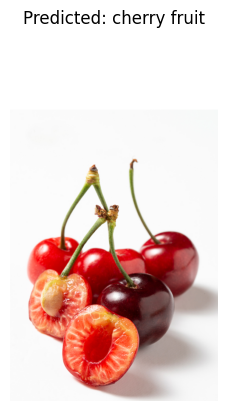

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


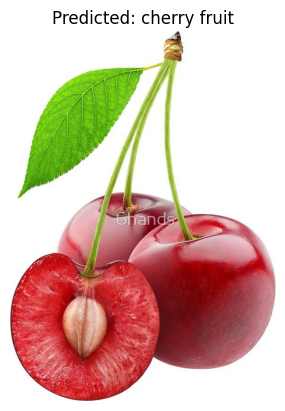

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


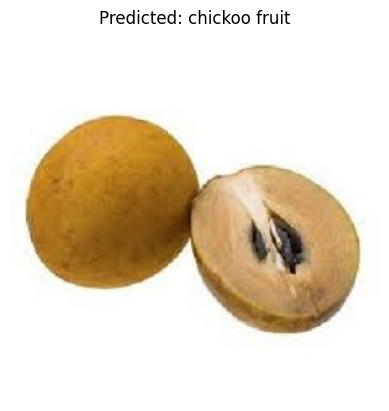

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


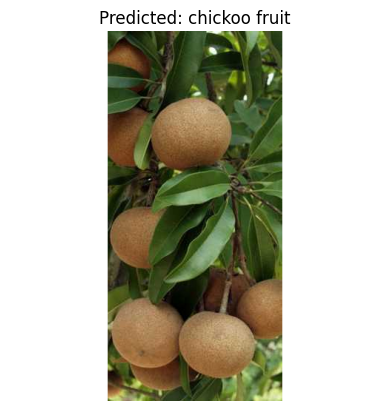

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


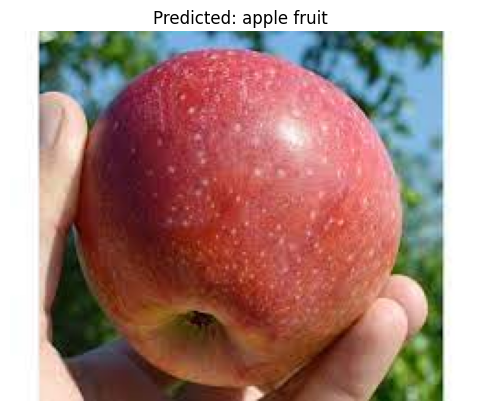

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


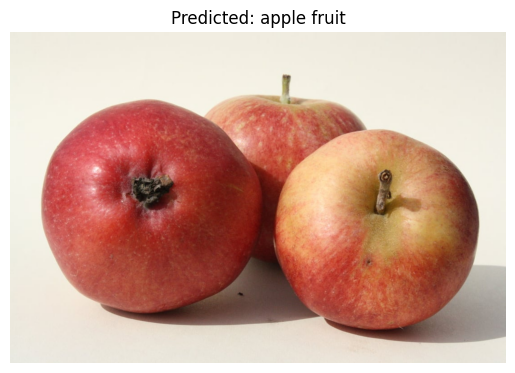

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


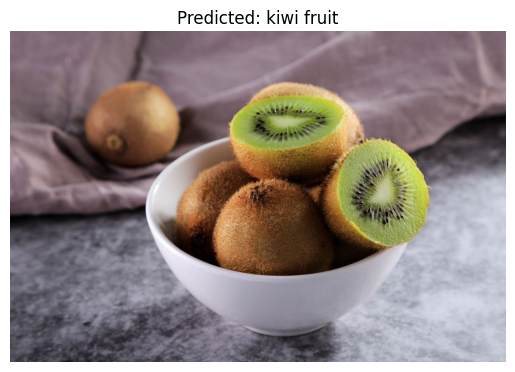

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


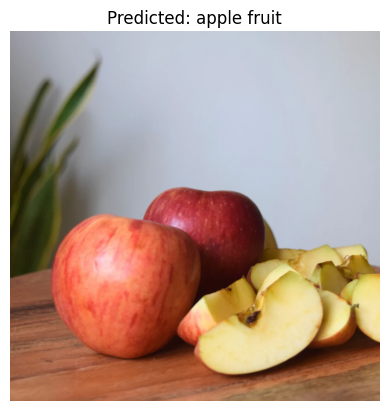

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


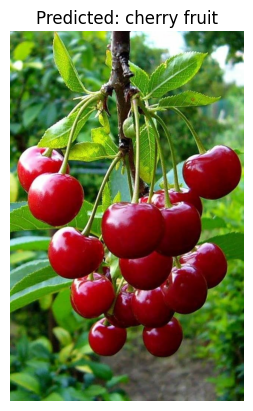

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


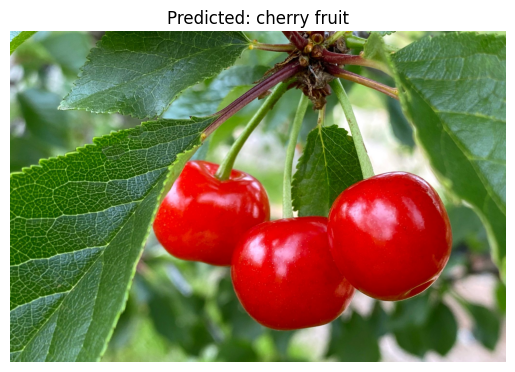

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


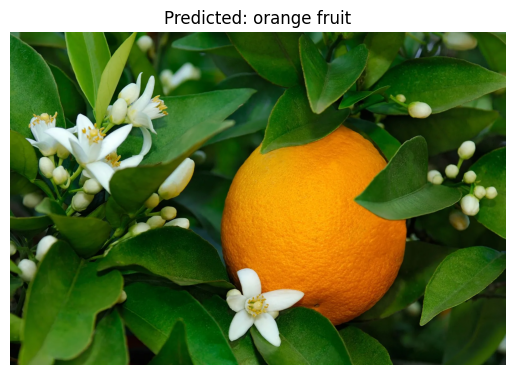

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


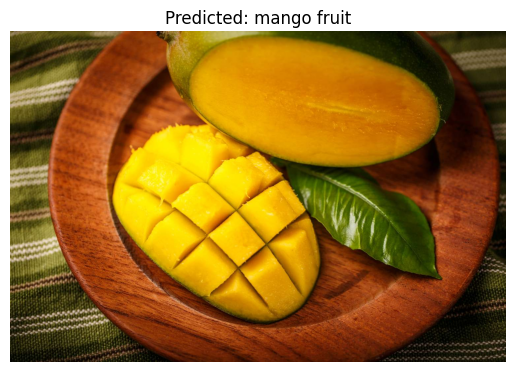

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


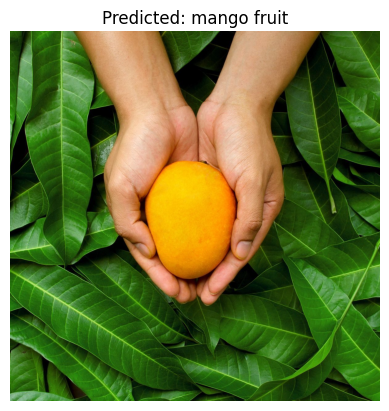

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


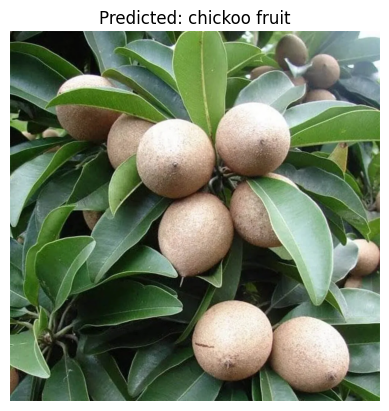

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


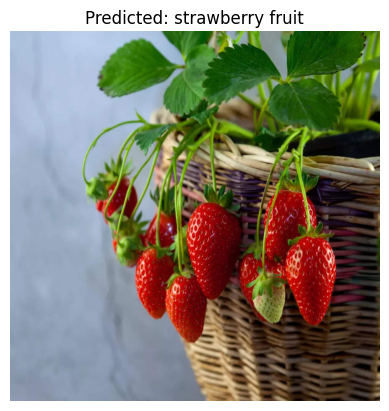

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


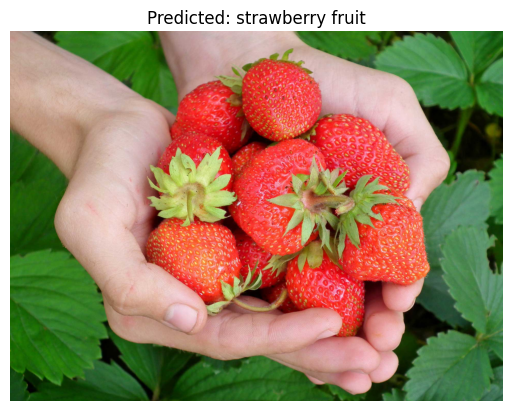

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


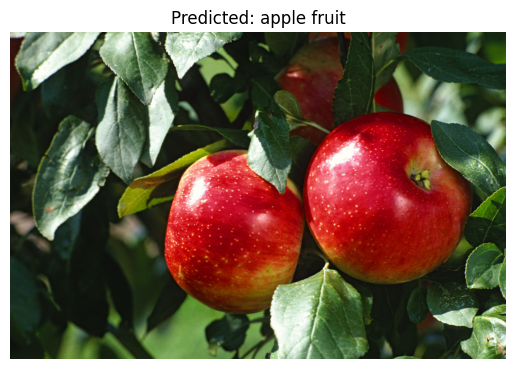

In [32]:
# Cell 18: Test the model on a few images
test_images = [
"D:/Feature Detection/test folder/01-Benefits-of-Cherry.jpg",
"D:/Feature Detection/test folder/480fc79588a5a07b96639d7aa2bae40d.jpg",
"D:/Feature Detection/test folder/1615394378008.jpg",
"D:/Feature Detection/test folder/fresh-cheeku.jpg",
"D:/Feature Detection/test folder/images.jpg",
"D:/Feature Detection/test folder/JZ3wWiMeCSnLN5tlO82NFueW0J9dMMqdlZ4Igf8N.jpg",
"D:/Feature Detection/test folder/kiwi-64037bd86ce73.jpg",
"D:/Feature Detection/feature_detection/Images FD/Untitleddesign_16.webp",
"D:/Feature Detection/feature_detection/Images FD/618flJ0XILL._AC_UF1000,1000_QL80_.jpg",
"D:/Feature Detection/feature_detection/Images FD/2048x1365-SEO-Morello-cherry-GettyImages-1330319873-e389763.jpg",
"D:/Feature Detection/feature_detection/Images FD/blossom-fruit-orange.webp",
"D:/Feature Detection/feature_detection/Images FD/GettyImages-1392614128-b6ff76b34a7f429995ed571015d1a680.jpg",
"D:/Feature Detection/feature_detection/Images FD/mango-shutterstock_1096844858.jpg",
"D:/Feature Detection/feature_detection/Images FD/product-jpeg-1000x1000.webp",
"D:/Feature Detection/feature_detection/Images FD/strawberries_istock.jpg",
"D:/Feature Detection/feature_detection/Images FD/Strawberry.jpg",
"D:/Feature Detection/feature_detection/Images FD/Two apples close-up_screen.jpg",
]

for image_path in test_images:
    # Preprocess the image
    image = prepare_image(image_path)
    
    # Make a prediction
    preds = model.predict(image)
    pred_label = lb.classes_[np.argmax(preds)]
    
    # Display the image and the prediction
    plt.figure()
    img = load_img(image_path)
    plt.imshow(img)
    plt.title(f"Predicted: {pred_label}")
    plt.axis("off")
    plt.show()
